# asymptotics — Transcendental Equations & Systems

This notebook covers transcendental equations and coupled transcendental systems.
Functions like `cos`, `sin`, `exp`, `log`, `tan` work out of the box in equation strings.

**Part 1** — single transcendental equations  
**Part 2** — coupled transcendental systems

In [1]:
from asymptotics import AlgebraicEquation, AlgebraicSystem
%config InlineBackend.figure_format = 'svg'

---
# Part 1 — Single transcendental equations

## Example 1 — Perturbed tangent

$$\tan x - 1 - \varepsilon x^2 = 0, \qquad x_0 = \tfrac{\pi}{4}$$

Appears in waveguide theory and quantum well eigenvalue problems.

In [2]:
eq  = AlgebraicEquation("tan(x) - 1 - eps*x**2", dependent="x", small_param="eps")
sol = eq.expand_regular(order=3)
sol.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

{'eps': array([0.01, 0.05, 0.1 , 0.2 , 0.4 ]),
 'perturbation': array([0.78849716, 0.80119135, 0.81774502, 0.85323352, 0.9344332 ]),
 'numerical': array([0.78849716, 0.80119107, 0.8177401 , 0.8531411 , 0.93246633]),
 'fig': <Figure size 500x400 with 1 Axes>}

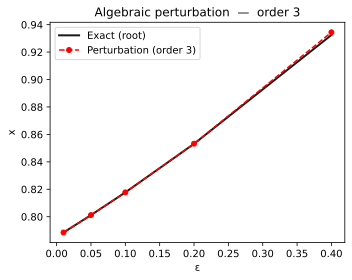

In [3]:
sol.compare_numeric(eps=[0.01, 0.05, 0.1, 0.2, 0.4])

## Example 2 — $x \ln x = \varepsilon$

$$x \ln x - \varepsilon = 0, \qquad x_0 = 1$$

In [4]:
eq  = AlgebraicEquation("x*log(x) - eps", dependent="x", small_param="eps")
sol = eq.expand_regular(order=3)
sol.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

{'eps': array([0.01, 0.05, 0.1 , 0.2 , 0.3 ]),
 'perturbation': array([1.00995067, 1.04883333, 1.09566667, 1.18533333, 1.273     ]),
 'numerical': array([1.00995066, 1.04882691, 1.09557192, 1.18402065, 1.26713103]),
 'fig': <Figure size 500x400 with 1 Axes>}

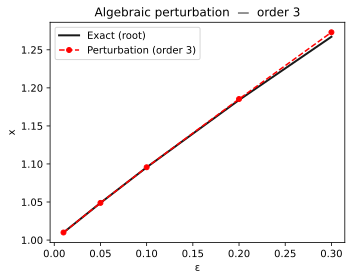

In [5]:
sol.compare_numeric(eps=[0.01, 0.05, 0.1, 0.2, 0.3])

## Example 3 — Exponential fixed point

$$x - e^{-\varepsilon x} = 0, \qquad x_0 = 1$$

Fixed point of $g(x) = e^{-\varepsilon x}$ — population dynamics, queueing theory.

In [6]:
eq  = AlgebraicEquation("x - exp(-eps*x)", dependent="x", small_param="eps")
sol = eq.expand_regular(order=3)
sol.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

{'eps': array([0.01, 0.05, 0.1 ]),
 'perturbation': array([0.99014733, 0.95341667, 0.91233333]),
 'numerical': array([0.99014738, 0.95344617, 0.91276527]),
 'fig': <Figure size 500x400 with 1 Axes>}

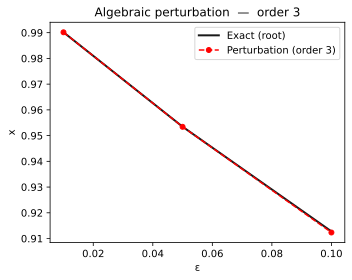

In [7]:
sol.compare_numeric(eps=[0.01, 0.05, 0.1])

## Example 4 — Logarithmic equation near $x = e$

$$\ln x + \varepsilon x - 1 = 0, \qquad x_0 = e$$

Illustrates **growing coefficients** — a signal of limited convergence radius.

In [8]:
eq  = AlgebraicEquation("log(x) + eps*x - 1", dependent="x", small_param="eps")
sol = eq.expand_regular(order=3)
sol.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⚠️  Coefficients grow as powers of e — valid only for very small ε


{'eps': array([0.01, 0.05, 0.1 ]),
 'perturbation': array([2.6472585 , 2.4059504 , 2.13506421]),
 'numerical': array([2.64726582, 2.4097274 , 2.18479231]),
 'fig': <Figure size 500x400 with 1 Axes>}

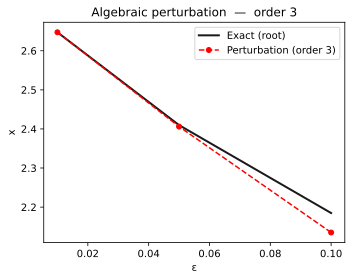

In [9]:
print('⚠️  Coefficients grow as powers of e — valid only for very small ε')
sol.compare_numeric(eps=[0.01, 0.05, 0.1])

---
# Part 2 — Coupled transcendental systems

## System 1 — Symmetric exponential fixed-point system

$$x - e^{-\varepsilon y} = 0, \qquad y - e^{-\varepsilon x} = 0$$

**Context:** two mutually interacting populations each regulated by the other.

**Unperturbed solution** ($\varepsilon = 0$): $x_0 = y_0 = 1$.

By symmetry, $x(\varepsilon) = y(\varepsilon)$ — perturbation theory should reflect this.

In [10]:
sys1 = AlgebraicSystem(
    equations   = ["x - exp(-eps*y)", "y - exp(-eps*x)"],
    dependents  = ["x", "y"],
    small_param = "eps",
)

sol1 = sys1.expand_regular(order=3)
sol1.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

{'eps': array([0.01, 0.05, 0.1 , 0.2 ]),
 'perturbation': {'x': array([0.99014733, 0.95341667, 0.91233333, 0.83866667]),
  'y': array([0.99014733, 0.95341667, 0.91233333, 0.83866667])},
 'numerical': {'x': array([0.99014738, 0.95344617, 0.91276527, 0.84457987]),
  'y': array([0.99014738, 0.95344617, 0.91276527, 0.84457987])},
 'fig': <Figure size 1000x400 with 2 Axes>}

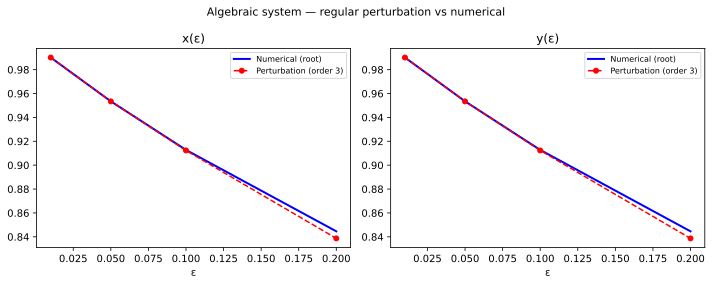

In [18]:
sol1.compare_numeric(eps=[0.01, 0.05, 0.1, 0.2])

## System 2 — sin/cos coupling

$$x - \sin(\varepsilon y) - 1 = 0, \qquad y - \cos(\varepsilon x) = 0$$

**Unperturbed solution** ($\varepsilon = 0$): $x_0 = 1$, $y_0 = 1$ (since $\cos(0) = 1$).

The coupling through $\sin$ and $\cos$ creates an interesting asymmetric correction.

In [19]:
sys2 = AlgebraicSystem(
    equations   = ["x - sin(eps*y) - 1", "y - cos(eps*x)"],
    dependents  = ["x", "y"],
    small_param = "eps",
)

sol2 = sys2.expand_regular(order=3)
sol2.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

{'eps': array([0.01, 0.05, 0.1 , 0.2 , 0.3 ]),
 'perturbation': {'x': array([1.00999933, 1.04991667, 1.09933333, 1.19466667, 1.282     ]),
  'y': array([0.999949, 0.998625, 0.994   , 0.972   , 0.928   ])},
 'numerical': {'x': array([1.00999932, 1.04991038, 1.09923287, 1.19311204, 1.27474911]),
  'y': array([0.999949  , 0.99862243, 0.99396452, 0.97166451, 0.92776252])},
 'fig': <Figure size 1000x400 with 2 Axes>}

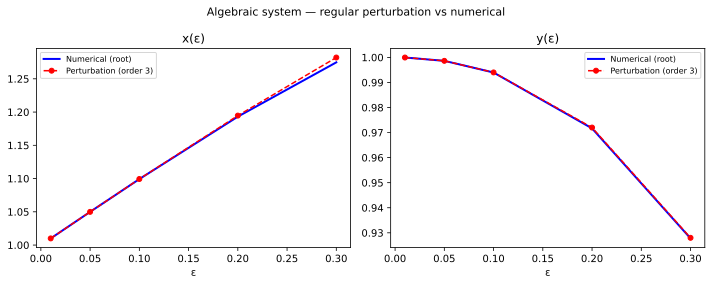

In [20]:
sol2.compare_numeric(eps=[0.01, 0.05, 0.1, 0.2, 0.3])

## System 3 — Coupled logarithmic system

$$\ln x + \varepsilon y - 1 = 0, \qquad \ln y + \varepsilon x - 1 = 0$$

**Unperturbed solution** ($\varepsilon = 0$): $x_0 = y_0 = e$.

Like the scalar log case, coefficients involve powers of $e$ — expect limited convergence.

In [14]:
sys3 = AlgebraicSystem(
    equations   = ["log(x) + eps*y - 1", "log(y) + eps*x - 1"],
    dependents  = ["x", "y"],
    small_param = "eps",
)

sol3 = sys3.expand_regular(order=3)
sol3.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⚠️  Coefficients grow as powers of e — valid only for very small ε


{'eps': array([0.01, 0.05, 0.1 ]),
 'perturbation': {'x': array([2.6472585 , 2.4059504 , 2.13506421]),
  'y': array([2.6472585 , 2.4059504 , 2.13506421])},
 'numerical': {'x': array([2.64726582, 2.4097274 , 2.18479231]),
  'y': array([2.64726582, 2.4097274 , 2.18479231])},
 'fig': <Figure size 1000x400 with 2 Axes>}

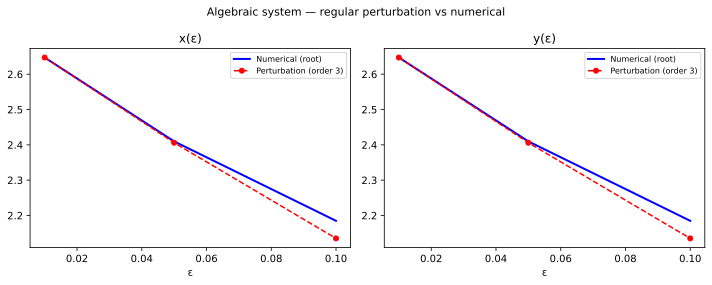

In [15]:
print('⚠️  Coefficients grow as powers of e — valid only for very small ε')
sol3.compare_numeric(eps=[0.01, 0.05, 0.1])

## System 4 — Mixed polynomial/trigonometric

$$x^2 + \varepsilon \sin y - 1 = 0, \qquad y - \varepsilon \cos x = 0$$

**Unperturbed solution** ($\varepsilon = 0$): $x_0 = 1$, $y_0 = 0$.

The two equations have very different character — one polynomial, one transcendental — yet perturbation theory handles them uniformly.

In [16]:
sys4 = AlgebraicSystem(
    equations   = ["x**2 + eps*sin(y) - 1", "y - eps*cos(x)"],
    dependents  = ["x", "y"],
    small_param = "eps",
)

sol4 = sys4.expand_regular(order=3)
sol4.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

{'eps': array([0.01, 0.05, 0.1 , 0.2 , 0.5 ]),
 'perturbation': {'x': array([0.99997298, 0.99932462, 0.99729849, 0.98919395, 0.93246221]),
  'y': array([0.00540325, 0.02704353, 0.05425755, 0.10987906, 0.2985667 ])},
 'numerical': {'x': array([0.99997298, 0.99932376, 0.99728472, 0.98897028, 0.92269298]),
  'y': array([0.00540325, 0.02704356, 0.05425851, 0.10991009, 0.30183771])},
 'fig': <Figure size 1000x400 with 2 Axes>}

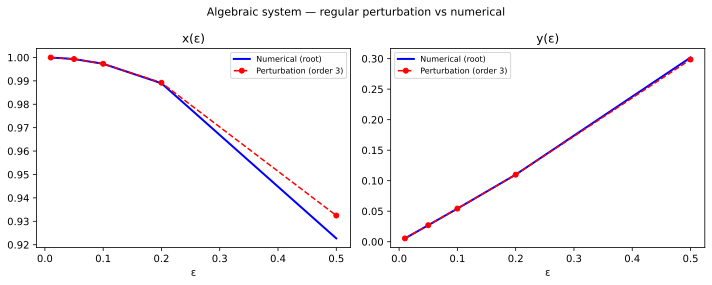

In [17]:
sol4.compare_numeric(eps=[0.01, 0.05, 0.1, 0.2, 0.5])

---
## Summary

| System | $x_0, y_0$ | Character |
|:---|:---:|:---:|
| $x = e^{-\varepsilon y},\; y = e^{-\varepsilon x}$ | $1, 1$ | Symmetric, good convergence |
| $x - \sin(\varepsilon y) = 1,\; y = \cos(\varepsilon x)$ | $1, 1$ | Asymmetric corrections |
| $\ln x + \varepsilon y = 1,\; \ln y + \varepsilon x = 1$ | $e, e$ | Coefficients grow as $e^n$ |
| $x^2 + \varepsilon \sin y = 1,\; y = \varepsilon \cos x$ | $1, 0$ | Mixed polynomial/trig |

**The workflow is identical regardless of complexity:**

```python
sys = AlgebraicSystem(
    equations   = ["f1(x, y, eps)", "f2(x, y, eps)"],
    dependents  = ["x", "y"],
    small_param = "eps",
)
sol = sys.expand_regular(order=3)
sol.show()
sol["x"].composite   # x(ε)
sol["y"].composite   # y(ε)
```